# CNN Basics — Convolutional Neural Networks

## Goal
Understand how CNNs detect patterns using filters.
CNNs revolutionized computer vision — and the same ideas appear in NLP.

## Key Questions
- What is a convolution and what does it detect?
- How do filters learn to recognize patterns?
- What is pooling and why does it matter?

## What We Build
A CNN from scratch using numpy — implementing convolution and pooling manually.
Then we use PyTorch to train a simple CNN on real data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## 1. What is Convolution?
A filter slides over the input and detects patterns.
Different filters detect different features — edges, curves, textures.

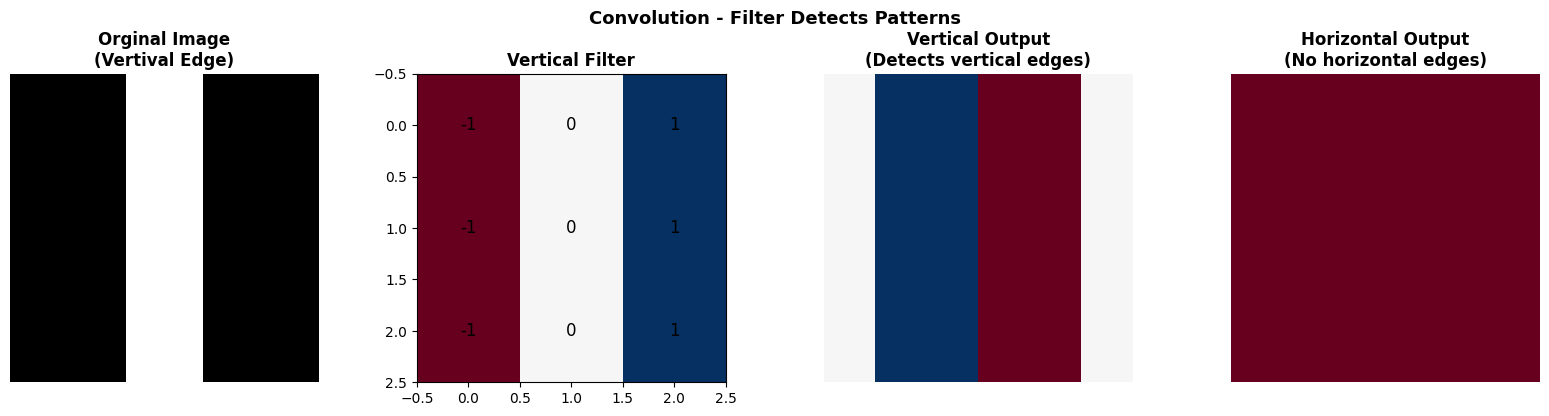

Image shape: (8, 8)
Filter shape: (3, 3)
Output shape: (6, 6)


In [4]:
# Create a simple 8x8 image — a vertical edge
image = np.array([
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
], dtype=float)

# Filters — each detects a different pattern
vertical_filter = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
])

horizontal_filter = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1],
])

def convolved2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Apply a convolution filter to an image."""
    h, w = image.shape
    kh, kw = kernel.shape
    output_h = h - kh + 1
    output_w = w - kw + 1
    output = np.zeros((output_h, output_w))

    for i in range(output_h):
        for j in range(output_w):
            output[i, j] = np.sum(image[i:i+kh, j:j+kw] * kernel)

    return output

# Apply filters
vertical_output = convolved2d(image, vertical_filter)
horizontal_output = convolved2d(image, horizontal_filter)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Orginal Image\n(Vertival Edge)", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(vertical_filter, cmap="RdBu")
axes[1].set_title("Vertical Filter", fontweight="bold")
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, str(vertical_filter[i, j]), ha="center", va="center", fontsize=12)

axes[2].imshow(vertical_output, cmap="RdBu")
axes[2].set_title(f"Vertical Output\n(Detects vertical edges)", fontweight="bold")
axes[2].axis("off")

axes[3].imshow(horizontal_output, cmap="RdBu")
axes[3].set_title(f"Horizontal Output\n(No horizontal edges)", fontweight="bold")
axes[3].axis("off")

plt.suptitle("Convolution - Filter Detects Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Convolution.png", dpi=300)
plt.show()

print(f"Image shape: {image.shape}")
print(f"Filter shape: {vertical_filter.shape}")
print(f"Output shape: {vertical_output.shape}")